# **Prediccion de supervivencia en pacientes con cancer de pulmon**

## **Instalar librerias(pycaret) e importarlas**

advertencia de que se reinstalen librerias antiguas para pycaret

In [1]:
#!pip install pycaret[full]

## **Importar**

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
from pycaret.classification import *

# **1. Integracion y recopilacion**

El dataset se encuentra en un solo archivo csv




In [3]:
PATH_DATASET = 'https://drive.google.com/uc?export=download&id=1WzIWYlMhHuhe6f6SadMaSlDfT2iNZWSo'

# No se usaran las columnas country, diagnosis_date, end_treatment_date
df = pd.read_csv(PATH_DATASET, header = 0) #usecols=['age', 'gender', 'cancer_stage', 'family_history', 'smoking_status', 'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type', 'survived'])
## Todas las columnas de dataset
print("="*60)
print("COLUMNAS INICIALES DEL DATASET")
print("="*60)
print(df.columns)
print("Cantidad de Columnas: ", df.shape[1])
duplicados = df.duplicated().sum()
if duplicados == 0:
  print("NO PRESENTA FILAS DATOS DUPLICADAS")
else:
  print("CANTIDAD DE DUPLICADOS: ", duplicados)

COLUMNAS INICIALES DEL DATASET
Index(['id', 'age', 'gender', 'country', 'diagnosis_date', 'cancer_stage',
       'family_history', 'smoking_status', 'bmi', 'cholesterol_level',
       'hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'treatment_type',
       'end_treatment_date', 'survived'],
      dtype='object')
Cantidad de Columnas:  17
NO PRESENTA FILAS DATOS DUPLICADAS


## **1.1 Obtener las primeras columnas de interes**

### **1.1.1 Se crea una nueva columna, total de dias de tratamiento**

In [4]:
## Eliminar columnas que no son de interes inicial (para la prediccion de supervivencia {0,1}) ['id', 'country', 'diagnosis_date', 'end_treatment_date']
### Crear una columna con las fechas


df["diagnosis_date"] = pd.to_datetime(df["diagnosis_date"])
df["end_treatment_date"] = pd.to_datetime(df["end_treatment_date"])
df["total_treatment_days"] = (df["end_treatment_date"] - df["diagnosis_date"]).dt.days

df.drop(columns=['id', 'country', 'diagnosis_date', 'end_treatment_date'], inplace=True)

print("="*60)
print("COLUMNAS DE INTERES")
print("="*60)
print(df.columns)
print("Cantidad de Columnas: ", df.shape[1])

print("="*60)
print("PRIMEROS 5 FILAS DEL DATASET")
print("="*60)
print(df.head())

print("="*60)
print("ULTIMAS 5 FILAS DEL DATASET")
print("="*60)
print(df.tail())

COLUMNAS DE INTERES
Index(['age', 'gender', 'cancer_stage', 'family_history', 'smoking_status',
       'bmi', 'cholesterol_level', 'hypertension', 'asthma', 'cirrhosis',
       'other_cancer', 'treatment_type', 'survived', 'total_treatment_days'],
      dtype='object')
Cantidad de Columnas:  14
PRIMEROS 5 FILAS DEL DATASET
    age  gender cancer_stage family_history  smoking_status   bmi  \
0  64.0    Male      Stage I            Yes  Passive Smoker  29.4   
1  50.0  Female    Stage III            Yes  Passive Smoker  41.2   
2  65.0  Female    Stage III            Yes   Former Smoker  44.0   
3  51.0  Female      Stage I             No  Passive Smoker  43.0   
4  37.0    Male      Stage I             No  Passive Smoker  19.7   

   cholesterol_level  hypertension  asthma  cirrhosis  other_cancer  \
0                199             0       0          1             0   
1                280             1       1          0             0   
2                268             1       1     

# **2. Analisis Exploratorio de Datos**

## **2.1 Graficar Datos y Analisis Exploratorio**

INFORMACION BASICA DEL DATASET
Dimensiones: 890000 filas x 14 columnas

TIPOS DE DATOS:
age                     float64
gender                   object
cancer_stage             object
family_history           object
smoking_status           object
bmi                     float64
cholesterol_level         int64
hypertension              int64
asthma                    int64
cirrhosis                 int64
other_cancer              int64
treatment_type           object
survived                  int64
total_treatment_days      int64
dtype: object

VALORES FALTANTES:
No hay valores faltantes

ESTADISTICAS DESCRIPTIVAS:
             age        bmi  cholesterol_level  hypertension     asthma  \
count  890000.00  890000.00          890000.00     890000.00  890000.00   
mean       55.01      30.49             233.63          0.75       0.47   
std         9.99       8.37              43.43          0.43       0.50   
min         4.00      16.00             150.00          0.00       0.00   
25

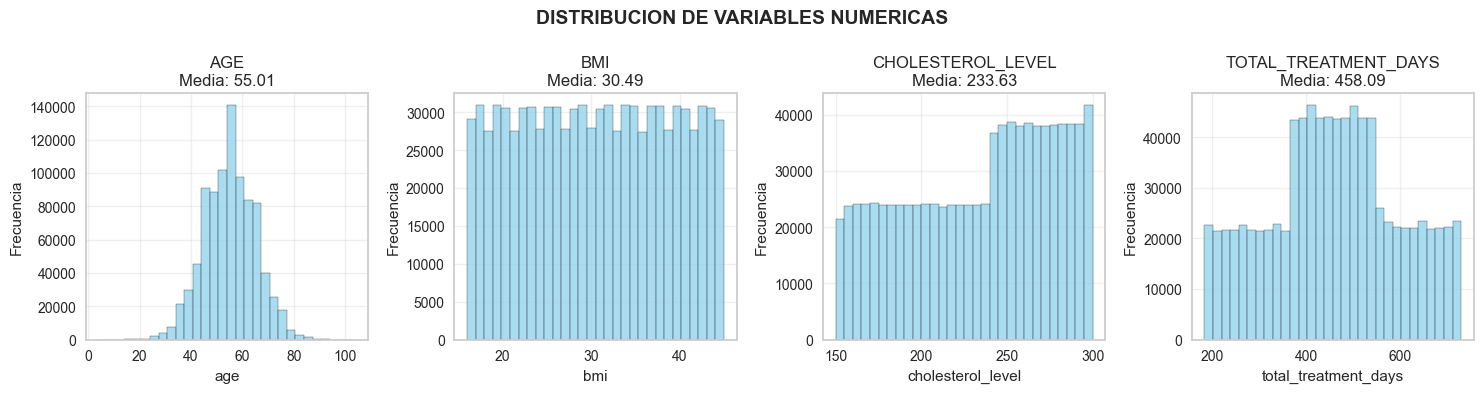

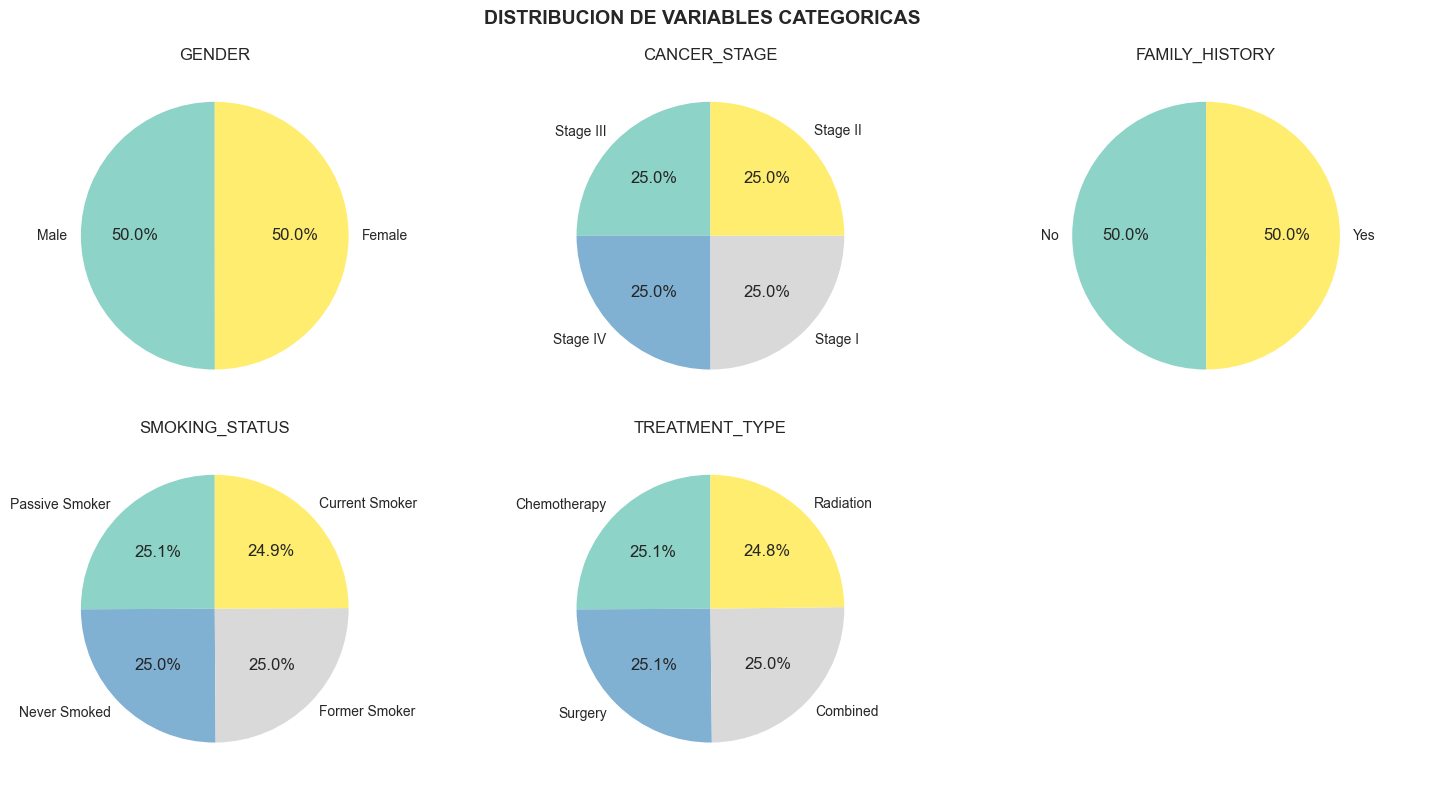

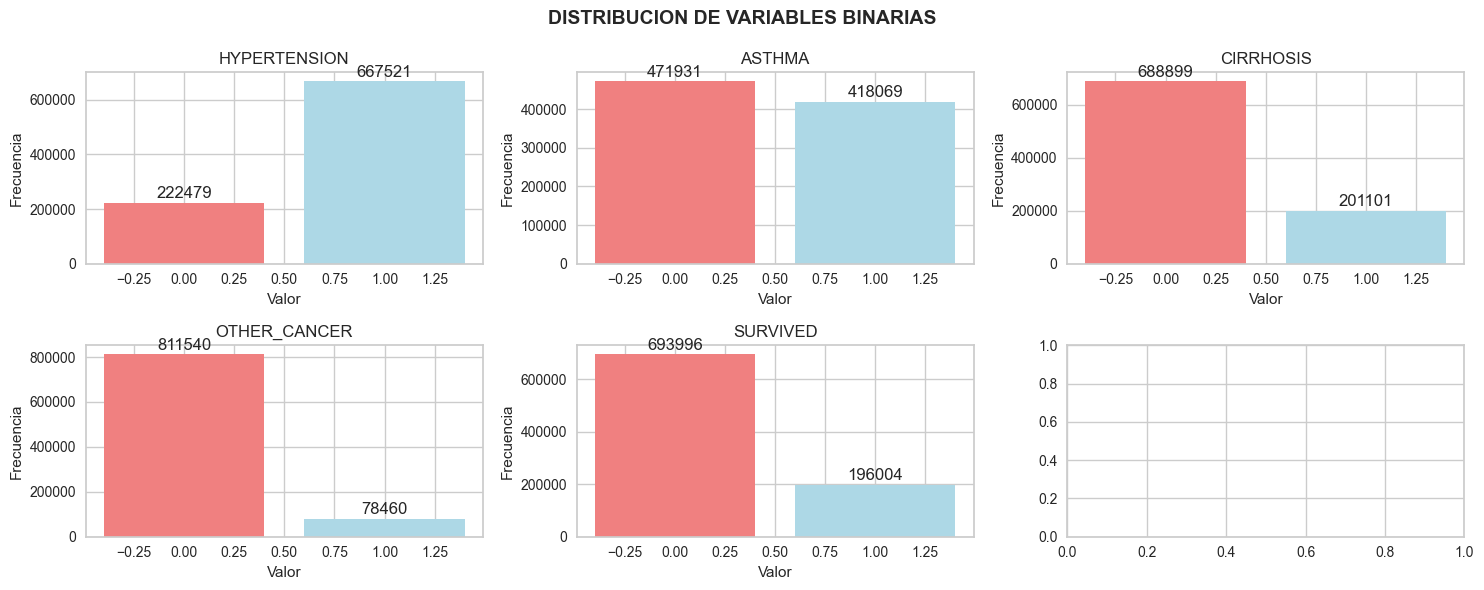

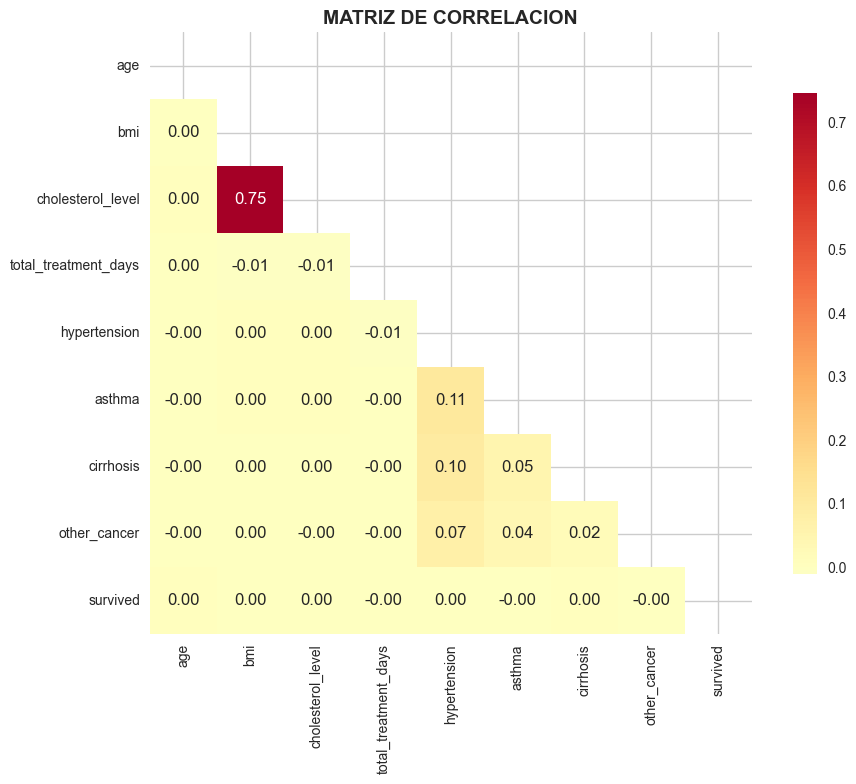


CORRELACIONES MAS FUERTES (|r| > 0.3):
bmi <-> cholesterol_level: 0.747

ANALISIS COMPLETADO


In [5]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Configuracion de estilo
import seaborn as sns
#sns.set_style('seaborn-v0_8')
sns.set_palette("husl")

print("="*50)
print("INFORMACION BASICA DEL DATASET")
print("="*50)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

print("\nTIPOS DE DATOS:")
print(df.dtypes)

print("\nVALORES FALTANTES:")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        'Columna': missing_data.index,
        'Valores Faltantes': missing_data.values,
        'Porcentaje (%)': missing_percent.values
    })
    print(missing_df[missing_df['Valores Faltantes'] > 0])
else:
    print("No hay valores faltantes")

print("\nESTADISTICAS DESCRIPTIVAS:")
print(df.describe().round(2))

# Separar variables por tipo
numeric_cols = ['age', 'bmi', 'cholesterol_level', 'total_treatment_days']
categorical_cols = ['gender', 'cancer_stage', 'family_history', 'smoking_status', 'treatment_type']
binary_cols = ['hypertension', 'asthma', 'cirrhosis', 'other_cancer', 'survived'] # 0 o 1, se puede catalogar como una variable categorica

# Visualizaciones para variables numericas
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle('DISTRIBUCION DE VARIABLES NUMERICAS', fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=30, alpha=0.7, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'{col.upper()}\nMedia: {df[col].mean():.2f}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualizaciones para variables categoricas
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('DISTRIBUCION DE VARIABLES CATEGORICAS', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    value_counts = df[col].value_counts()
    colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))

    axes[i].pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[i].set_title(f'{col.upper()}')

# Ocultar eje vacio
axes[5].axis('off')

plt.tight_layout()
plt.show()

# Visualizaciones para variables binarias
fig, axes = plt.subplots(2, 3, figsize=(15, 6))
fig.suptitle('DISTRIBUCION DE VARIABLES BINARIAS', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df[col].value_counts().sort_index()
    colors = ['lightcoral', 'lightblue']

    bars = axes[i].bar(counts.index, counts.values, color=colors[:len(counts)])
    axes[i].set_title(f'{col.upper()}')
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

    # Agregar valores en las barras
    for bar, count in zip(bars, counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(counts.values),
                    f'{count}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Matriz de correlacion
numeric_df = df[numeric_cols + binary_cols ]

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()

# Crear heatmap
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdYlBu_r',
           center=0, square=True, fmt='.2f', cbar_kws={"shrink": .8})
plt.title('MATRIZ DE CORRELACION', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Correlaciones fuertes
print("\nCORRELACIONES MAS FUERTES (|r| > 0.3):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.3:
            high_corr.append((correlation_matrix.columns[i],
                            correlation_matrix.columns[j], corr_val))

if high_corr:
    for var1, var2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"{var1} <-> {var2}: {corr:.3f}")
else:
    print("No se encontraron correlaciones fuertes")

print("\nANALISIS COMPLETADO")

# **3. Limpieza de Datos y 4. Transformacion de Datos**

Limpieza de datos (Nulos, Outliers), Normalizacion y Balanceo con Pycaret

In [6]:
# Tipos de datos y nulos
print("="*60)
print("TIPOS DE DATOS Y NULOS")
print("="*60)
print(df.info())

# Estadísticas de todas las columnas
print("="*60)
print("ESTADISTICAS DE COLUMNAS")
print("="*60)
print(df.describe(include='all'))

TIPOS DE DATOS Y NULOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890000 entries, 0 to 889999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   890000 non-null  float64
 1   gender                890000 non-null  object 
 2   cancer_stage          890000 non-null  object 
 3   family_history        890000 non-null  object 
 4   smoking_status        890000 non-null  object 
 5   bmi                   890000 non-null  float64
 6   cholesterol_level     890000 non-null  int64  
 7   hypertension          890000 non-null  int64  
 8   asthma                890000 non-null  int64  
 9   cirrhosis             890000 non-null  int64  
 10  other_cancer          890000 non-null  int64  
 11  treatment_type        890000 non-null  object 
 12  survived              890000 non-null  int64  
 13  total_treatment_days  890000 non-null  int64  
dtypes: float64(2), int64(7), obje

## **3.1. Nulos**

In [7]:
##### USANDO PYCARET PARA MISSING #####
#> pip install pycaret
## :( Aparece error y advertencias

# Conteo de nulos por columna
print("="*60)
print("CONTEO DE NULOS POR COLUMNA")
print("="*60)
print(df.isnull().sum())

CONTEO DE NULOS POR COLUMNA
age                     0
gender                  0
cancer_stage            0
family_history          0
smoking_status          0
bmi                     0
cholesterol_level       0
hypertension            0
asthma                  0
cirrhosis               0
other_cancer            0
treatment_type          0
survived                0
total_treatment_days    0
dtype: int64


## **3.2. Outliers**

Columnas Numericas:  ['age', 'bmi', 'cholesterol_level', 'total_treatment_days']
------------------------------
age
count    890000.000000
mean         55.007008
std           9.994485
min           4.000000
25%          48.000000
50%          55.000000
75%          62.000000
max         104.000000
Name: age, dtype: float64
------------------------------
bmi
count    890000.000000
mean         30.494172
std           8.368539
min          16.000000
25%          23.300000
50%          30.500000
75%          37.700000
max          45.000000
Name: bmi, dtype: float64
------------------------------
cholesterol_level
count    890000.000000
mean        233.633916
std          43.432278
min         150.000000
25%         196.000000
50%         242.000000
75%         271.000000
max         300.000000
Name: cholesterol_level, dtype: float64
------------------------------
total_treatment_days
count    890000.000000
mean        458.087170
std         139.326048
min         183.000000
25%         

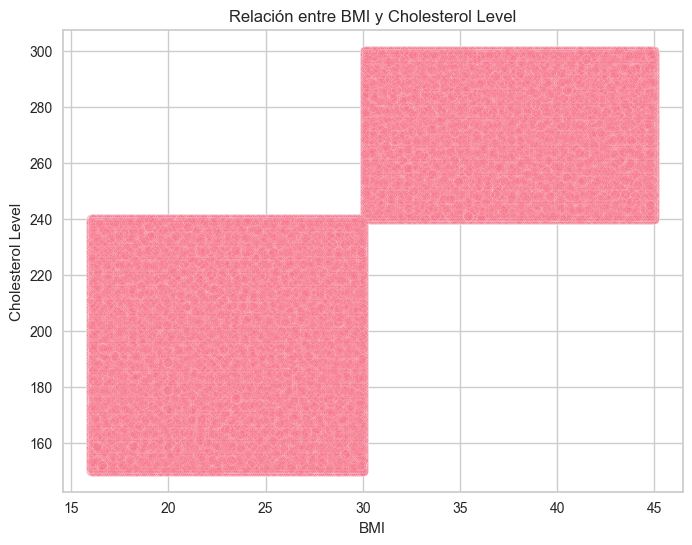

In [8]:
### Outliers de las Columnas Numericas (no incluye a los binarios [0,1])
print("="*60)
print("Columnas Numericas: ", numeric_cols)
print("="*60)

## se tiene tres variables numericas

for num in numeric_cols:
  print("-"*30)
  print(num)
  print(df[num].describe())

# Edad (considerando adultos 18-80 [esperana de vida en Peru = 77.5])
print(f"Dimensiones del DataFrame original: {df.shape}")
print(f"Rango de edad original: {df['age'].min()} - {df['age'].max()}")

# Definir los límites de edad
min_age = 18
max_age = 90

# Filtrar el DataFrame para incluir solo personas dentro del rango de edad deseado
df = df[
    (df['age'] >= min_age) & (df['age'] <= max_age)
].copy() # .copy() para evitar SettingWithCopyWarning

print(f"Dimensiones del DataFrame después de filtrar por edad: {df.shape}")
print(f"Nuevo rango de edad: {df['age'].min()} - {df['age'].max()}")



# Relacion entre BMI - COLESTEROL (MATRIZ DE CORRELACION)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='cholesterol_level', alpha=0.1)

plt.title('Relación entre BMI y Cholesterol Level')
plt.xlabel('BMI')
plt.ylabel('Cholesterol Level')
plt.grid(True)
plt.show()

Variabilidad de datos entre BMI y nivel de Colesterol

# **4. Transformacion de Datos**

## **4.1 Datos Categoricos a numericos**

In [9]:
print("="*60)
print("DATOS ANTES")
print("="*60)
for var in categorical_cols:
  print("-"*60)
  print(df[var].value_counts())

print("="*60)
print("TRANSFORMACION DE DATOS")
print("="*60)
'''
for var in categorical_cols:
  if var+'_T' in df.columns:
    df = df.drop(columns=[var+'_T'])
'''

# Transformar la columna 'gender'
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# Transformar la columna 'cancer_stage'
df['cancer_stage'] = df['cancer_stage'].map({
    'Stage I': 1,
    'Stage II': 2,
    'Stage III': 3,
    'Stage IV': 4
})

# Transformar la columna 'family_history'
df['family_history'] = df['family_history'].map({'No': 0, 'Yes': 1})

# Transformar la columna 'smoking_status'
df['smoking_status'] = df['smoking_status'].map({
    'Passive Smoker': 1,
    'Never Smoked': 2,
    'Former Smoker': 3,
    'Current Smoker': 4
})

# Transformar la columna 'treatment_type'
df['treatment_type'] = df['treatment_type'].map({
    'Chemotherapy': 1,
    'Surgery': 2,
    'Combined': 3,
    'Radiation': 4
})

print("="*60)
print("DATOS DESPUES")
print("="*60)
for var in categorical_cols:
  print("-"*60)
  print(df[var].value_counts())

print(df.info())

DATOS ANTES
------------------------------------------------------------
gender
Male      445011
Female    444742
Name: count, dtype: int64
------------------------------------------------------------
cancer_stage
Stage III    222538
Stage IV     222463
Stage I      222450
Stage II     222302
Name: count, dtype: int64
------------------------------------------------------------
family_history
No     445048
Yes    444705
Name: count, dtype: int64
------------------------------------------------------------
smoking_status
Passive Smoker    223109
Never Smoked      222676
Former Smoker     222119
Current Smoker    221849
Name: count, dtype: int64
------------------------------------------------------------
treatment_type
Chemotherapy    223212
Surgery         223200
Combined        222545
Radiation       220796
Name: count, dtype: int64
TRANSFORMACION DE DATOS
DATOS DESPUES
------------------------------------------------------------
gender
0    445011
1    444742
Name: count, dtype: int6

## **4.2. Normalizar datos**

In [10]:
### Normalizacion de datos (Numericos)
print("="*60)
print("NORMALIZACION DE DATOS")
print("="*60)
print(numeric_cols)

for var in numeric_cols:
  print("-"*60)
  print(df[var].describe())


NORMALIZACION DE DATOS
['age', 'bmi', 'cholesterol_level', 'total_treatment_days']
------------------------------------------------------------
count    889753.000000
mean         55.003164
std           9.975151
min          18.000000
25%          48.000000
50%          55.000000
75%          62.000000
max          90.000000
Name: age, dtype: float64
------------------------------------------------------------
count    889753.000000
mean         30.494193
std           8.368594
min          16.000000
25%          23.300000
50%          30.500000
75%          37.700000
max          45.000000
Name: bmi, dtype: float64
------------------------------------------------------------
count    889753.000000
mean        233.634064
std          43.433093
min         150.000000
25%         196.000000
50%         242.000000
75%         271.000000
max         300.000000
Name: cholesterol_level, dtype: float64
------------------------------------------------------------
count    889753.000000
mean  

## **4.3. Balancear datos**

In [11]:
#### Balanceo de datos (survived)
print("="*60)
print("BALANCEO DE DATOS")
print("="*60)
print(df['survived'].value_counts())

BALANCEO DE DATOS
survived
0    693806
1    195947
Name: count, dtype: int64


## **Duplicados**

In [12]:
### Eliminar duplicados
print("Cantidad de filas: ", df.shape[0])
duplicados = df.duplicated().sum()
if duplicados == 0:
  print("NO PRESENTA FILAS DATOS DUPLICADAS")
else:
  print("CANTIDAD DE DUPLICADOS: ", duplicados)
  #df = df.drop_duplicates()
  print("Cantidad de filas: ", df.shape[0])

Cantidad de filas:  889753
CANTIDAD DE DUPLICADOS:  1
Cantidad de filas:  889753


## **PREPROCESAMIENTO CON PYCARET (missing, outliers, normalizacion y balanceo)**

Tiempo aproximado: 5 min

In [13]:
print("="*60)
print("INFORMACIÓN DEL DATAFRAME ORIGINAL (TRANSFORMADO)")
print("="*60)
print(df.info())

print("-"*60)
print("Conteo de nulos por columna (antes de PyCaret setup):")
print(df.isnull().sum())

print("-"*60)
print("Conteo de clases de 'survived' (target) antes del balanceo:")
print(df['survived'].value_counts())

# **EL ÚNICO SETUP DE PYCARET**
print("="*60)
print("PYCARET SETUP: IMPUTACIÓN (en missing), OUTLIERS, NORMALIZACIÓN, BALANCEO, CODIFICACIÓN")
print("="*60)

categorical_cols_for_pycaret = ['gender', 'cancer_stage', 'family_history', 'smoking_status',
                                'treatment_type', 'hypertension', 'asthma', 'cirrhosis',
                                'other_cancer'
                                ]

master_setup = setup(
    data=df, # ¡Pasamos el DataFrame ORIGINAL con nulos y strings!
    target='survived', # Tu variable objetivo
    numeric_features=numeric_cols, # Columnas numéricas para normalizar y detectar outliers
    categorical_features=categorical_cols_for_pycaret, # Columnas categóricas (originales, PyCaret las codificará)

    # Configuración de imputación (PyCaret la aplica automáticamente a nulos)
    imputation_type='simple', # Por defecto, pero bueno especificar
    numeric_imputation='mean', # Imputar nulos en numéricas con la media
    categorical_imputation='mode', # Imputar nulos en categóricas con la moda

    # Configuración de detección y eliminación de Outliers
    remove_outliers=True,
    outliers_method='iforest',
    outliers_threshold=0.05,

    # Configuración de Normalización
    normalize=True,
    normalize_method='zscore', # O 'minmax', 'robust'

    # Configuración de Balanceo de la variable objetivo (tbm se usara a nivel de modelo si es muy diferente)
    fix_imbalance=True,
    fix_imbalance_method='SMOTE',

    session_id=123, # Para reproducibilidad
    use_gpu=True,
    verbose=False   # Suprimir mensajes detallados durante el setup
)

print("="*60)
print("PyCaret Setup Completo")
print("="*60)

# **Verificación de los pasos de preprocesamiento aplicados por PyCaret**
print("="*60)
print("VERIFICACIÓN DEL PIPELINE DE PYCARET")
print("="*60)

pipe = get_config('pipeline')
print("Pasos en el pipeline de PyCaret:", pipe.named_steps.keys())
for name, step in pipe.named_steps.items():
    print(f"  - {name}: {type(step).__name__}")

# Verificar si los nulos han sido imputados en el conjunto de entrenamiento procesado
X_train_processed = get_config('X_train')
y_train_processed = get_config('y_train')

print("-"*60)
print("Nulos en el DataFrame de entrenamiento procesado por PyCaret:")
print(X_train_processed.isnull().sum().sum()) # Debería ser 0 si la imputación funcionó

print("-"*60)
print("Dimensiones del DataFrame de entrenamiento procesado por PyCaret (después de outliers):", X_train_processed.shape)
print("Dimensiones del DataFrame de prueba procesado por PyCaret:", get_config('X_test').shape)

total_original_rows = df.shape[0]
total_processed_rows = X_train_processed.shape[0] + get_config('X_test').shape[0]
rows_removed_for_outliers = total_original_rows - total_processed_rows

print("-"*60)
print(f"Filas eliminadas (principalmente por outliers): {rows_removed_for_outliers} ({round(rows_removed_for_outliers / total_original_rows * 100, 2)}%)")

print("-"*60)
print("Estadísticas de las variables numéricas en el entrenamiento procesado (después de normalización):")
print(X_train_processed[numeric_cols].describe())

print("-"*60)
print("Conteo de clases de 'survived' en el entrenamiento procesado (después del balanceo):")
print(y_train_processed.value_counts())

INFORMACIÓN DEL DATAFRAME ORIGINAL (TRANSFORMADO)
<class 'pandas.core.frame.DataFrame'>
Index: 889753 entries, 0 to 889999
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   age                   889753 non-null  float64
 1   gender                889753 non-null  int64  
 2   cancer_stage          889753 non-null  int64  
 3   family_history        889753 non-null  int64  
 4   smoking_status        889753 non-null  int64  
 5   bmi                   889753 non-null  float64
 6   cholesterol_level     889753 non-null  int64  
 7   hypertension          889753 non-null  int64  
 8   asthma                889753 non-null  int64  
 9   cirrhosis             889753 non-null  int64  
 10  other_cancer          889753 non-null  int64  
 11  treatment_type        889753 non-null  int64  
 12  survived              889753 non-null  int64  
 13  total_treatment_days  889753 non-null  int64  
dtypes: floa

## **Verificacion despues del setup**

In [14]:
# Después de haber ejecutado master_setup = setup(...)

# Obtener el DataFrame de prueba preprocesado
X_test_processed = get_config('X_test')
y_test_processed = get_config('y_test')

print("Dimensiones del X_train preprocesado:", X_train_processed.shape)
print("Dimensiones del y_train preprocesado:", y_train_processed.shape)
print("Dimensiones del X_test preprocesado:", X_test_processed.shape)
print("Dimensiones del y_test preprocesado:", y_test_processed.shape)

# Puedes ver las primeras filas de los datos preprocesados
print("\nPrimeras filas de X_train_processed:")
print(X_train_processed.head())

# Y verificar el balanceo en y_train_processed
print("\nConteo de clases en y_train_processed:")
print(y_train_processed.value_counts())

Dimensiones del X_train preprocesado: (622827, 13)
Dimensiones del y_train preprocesado: (622827,)
Dimensiones del X_test preprocesado: (266926, 13)
Dimensiones del y_test preprocesado: (266926,)

Primeras filas de X_train_processed:
         age  gender  cancer_stage  family_history  smoking_status        bmi  \
330929  48.0       1             3               0               3  36.500000   
867406  35.0       1             1               0               3  26.600000   
436558  44.0       0             1               1               1  35.799999   
761245  59.0       1             3               0               3  41.099998   
531146  57.0       0             1               1               4  18.200001   

        cholesterol_level  hypertension  asthma  cirrhosis  other_cancer  \
330929                269             1       0          0             1   
867406                194             1       1          0             0   
436558                249             1       1    

### **Comparacion y afinacion para modelos (balanceo)**

In [15]:
print("Configuración de PyCaret completada. Ahora se procederá a la comparación y afinación de modelos.")

# --- scale_pos_weight para XGBoost/LightGBM ---

count_class_0 = 485664
count_class_1 = 137163
calculated_scale_pos_weight = count_class_0 / count_class_1
print(f"Calculado scale_pos_weight: {calculated_scale_pos_weight:.2f}")

Configuración de PyCaret completada. Ahora se procederá a la comparación y afinación de modelos.
Calculado scale_pos_weight: 3.54


# **5. Modelamiento con IA**

## **5.1. Modelos y entrenaiento inicial (compare_models)**

**Tiempo aproximado: > 1h o 2h**

In [16]:
# Con los siguientes modelos:
# Lista de los modelos a comparar
models_to_compare = ['lightgbm', 'xgboost', 'lr', 'catboost', 'rf']
print("="*60)
print(f"Comparando los modelos: {', '.join(models_to_compare)} con 5-fold CV")
print("Esto puede tomar tiempo.")
print("="*60)

Comparando los modelos: lightgbm, xgboost, lr, catboost, rf con 5-fold CV
Esto puede tomar tiempo.


**Verificar Modelos a usar**

In [17]:
models_df = models()
print(models_df)

[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: Intel(R) Iris(R) Xe Graphics, Vendor: Intel(R) Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves t

**Opciones de configuracion de Hiperparametros por cada modelo**

In [18]:
from sklearn.metrics import classification_report
# ============================================================
# DEFINICIÓN DE GRIDS DE HIPERPARÁMETROS PARA AFINACIÓN
# ============================================================
print("OPCIONES DE HIPERPARAMETROS PARA AJUSTE")
custom_grids = {
    'lightgbm': {
        'num_leaves': [40],
        'max_depth': [-1],
        'learning_rate': [0.05, 0.1, 0.05],
        'subsample': [0.8, 0.9],
        'n_estimators': [200],
        'colsample_bytree': [0.8, 0.9], # Submuestreo de características
        'reg_alpha': [0.0, 0.1], # Regularización L1
        'reg_lambda': [0.0, 0.1] # Regularización L2
    },
    'xgboost': {
        'max_depth': [7, 9],
        'learning_rate': [0.05, 0.1],
        'n_estimators': [200],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 0.9], # Submuestreo de características
        'gamma': [0.0, 0.1], # Reducción mínima de pérdida para hacer una división
        'min_child_weight': [5] # Peso mínimo de la instancia en un nodo hijo

    },
    'lr': {
        'C': [0.01, 0.1, 1.0, 2.0],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'] # Específico para compatibilidad con l1/l2
    },
    'catboost': {
        'iterations': [300],
        'learning_rate': [0.01, 0.05, 0.1, 0.15], # Tasa de aprendizaje
        'depth': [7, 9],
        'l2_leaf_reg': [3, 5],
        'border_count': [32, 64, 128, 254] # Número de puntos de división para características numéricas
    },
    'rf': {
        'n_estimators': [300],
        'max_depth': [30, 50, None],
        'min_samples_split': [2, 5, 10], # Mínimo de muestras para dividir un nodo
        'min_samples_leaf': [1, 2, 4], # Mínimo de muestras en una hoja
        'max_features': [0.7, 0.8, 0.9, 1.0, 'sqrt', 'log2'] # Número de características a considerar en cada división
    }
}

# Lista para almacenar los resultados de las métricas de cada modelo
metrics_results = []
final_models = {} # Para almacenar los modelos finalizados


print("============================================================")
print("INICIANDO ENTRENAMIENTO Y AFINACIÓN DE MODELOS PASO A PASO")
print("============================================================")

OPCIONES DE HIPERPARAMETROS PARA AJUSTE
INICIANDO ENTRENAMIENTO Y AFINACIÓN DE MODELOS PASO A PASO


## **Modelo LIGHTGBM**

**Solo creacion con Hiperparametros, Tiempo estimado: > 15 min aprox**

In [19]:
# ============================================================
# MODELO 1: LIGHTGBM
# ============================================================
print("Creacion y afinamiento de modelos (por defecto 10 folds)")
model_name = 'lightgbm'
print(f"\n--- Procesando modelo: {model_name.upper()} ---")
try:
    fixed_lgbm_params = {
        'num_leaves': 40,
        'max_depth': -1,
        'learning_rate': 0.05,
        'subsample': 0.8,
        'n_estimators': 150,
        'colsample_bytree': 0.8,
        'reg_alpha': 0.0,
        'reg_lambda': 0.0,
        'scale_pos_weight': calculated_scale_pos_weight
    }
    lgbm_model = create_model(model_name, **fixed_lgbm_params, verbose=False)
    final_lgbm = finalize_model(lgbm_model)
    save_model(final_lgbm, 'final_lightgbm_model_fixed_params')
    final_models[model_name] = final_lgbm
    print(f"  Modelo {model_name.upper()} creado, finalizado y guardado.")

    # Evaluar en el hold-out set (conjunto de prueba)
    predictions = predict_model(final_lgbm, verbose=False)
    target_col_name = master_setup.get_config('target_param')
    report = classification_report(predictions[target_col_name], predictions['prediction_label'], output_dict=True)
    metrics_results.append({
        'Model': model_name,
        'AUC': predictions['prediction_score'].mean(), # Placeholder, ya que predict_model no da AUC directamente para todo el set
        'Accuracy': report['accuracy'],
        'Recall': report['1']['recall'] if '1' in report else report['recall'], # Asumiendo 1 es la clase positiva
        'Prec.': report['1']['precision'] if '1' in report else report['precision'],
        'F1': report['1']['f1-score'] if '1' in report else report['f1-score'],
        'Kappa': 0, 'MCC': 0 # Estos no se obtienen directamente de classification_report
    })
    print(f"  Métricas para {model_name.upper()} en el conjunto de prueba calculadas.")
except Exception as e:
    print(f"  Error al procesar LightGBM: {e}")
    metrics_results.append({'Model': model_name, **{m: 0 for m in ['AUC', 'Accuracy', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']}})


Creacion y afinamiento de modelos (por defecto 10 folds)

--- Procesando modelo: LIGHTGBM ---
Transformation Pipeline and Model Successfully Saved
  Modelo LIGHTGBM creado, finalizado y guardado.
  Métricas para LIGHTGBM en el conjunto de prueba calculadas.


## **Modelo XGBoost**

**Solo creacion del modelo, Tiempo estimado: > 15 min aprox**

In [20]:
# ============================================================
# MODELO 2: XGBOOST
# ============================================================
model_name = 'xgboost'
print(f"\n--- Procesando modelo: {model_name.upper()} ---")
try:
    fixed_xgb_params = {
        'max_depth': 7,
        'learning_rate': 0.05,
        'n_estimators': 150,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'gamma': 0.0,
        'min_child_weight': 5,
        'scale_pos_weight': calculated_scale_pos_weight
    }
    xgb_model = create_model(model_name, **fixed_xgb_params, verbose=False)
    final_xgb = finalize_model(xgb_model)
    save_model(final_xgb, 'final_xgboost_model_fixed_params')
    final_models[model_name] = final_xgb
    print(f"  Modelo {model_name.upper()} creado, finalizado y guardado.")

    predictions = predict_model(final_xgb, verbose=False)
    target_col_name = master_setup.get_config('target_param')
    report = classification_report(predictions[target_col_name], predictions['prediction_label'], output_dict=True)
    metrics_results.append({
        'Model': model_name,
        'AUC': predictions['prediction_score'].mean(),
        'Accuracy': report['accuracy'],
        'Recall': report['1']['recall'] if '1' in report else report['recall'],
        'Prec.': report['1']['precision'] if '1' in report else report['precision'],
        'F1': report['1']['f1-score'] if '1' in report else report['f1-score'],
        'Kappa': 0, 'MCC': 0
    })
    print(f"  Métricas para {model_name.upper()} en el conjunto de prueba calculadas.")
except Exception as e:
    print(f"  Error al procesar XGBoost: {e}")
    metrics_results.append({'Model': model_name, **{m: 0 for m in ['AUC', 'Accuracy', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']}})



--- Procesando modelo: XGBOOST ---
Transformation Pipeline and Model Successfully Saved
  Modelo XGBOOST creado, finalizado y guardado.
  Métricas para XGBOOST en el conjunto de prueba calculadas.


## **Modelo LR (Regresion Logistica)**

**Solo creacion del modelo, Tiempo estimado: > 15 min aprox**

In [21]:
# ============================================================
# MODELO 3: REGRESIÓN LOGÍSTICA (LR)
# ============================================================
model_name = 'lr'
print(f"\n--- Procesando modelo: {model_name.upper()} ---")
try:
    fixed_lr_params = {
        'C': 1.0,
        'penalty': 'l2',
        'solver': 'liblinear'
        # LR no usa scale_pos_weight directamente
    }
    lr_model = create_model(model_name, **fixed_lr_params, verbose=False)
    final_lr = finalize_model(lr_model)
    save_model(final_lr, 'final_lr_model_fixed_params')
    final_models[model_name] = final_lr
    print(f"  Modelo {model_name.upper()} creado, finalizado y guardado.")

    predictions = predict_model(final_lr, verbose=False)
    target_col_name = master_setup.get_config('target_param')
    report = classification_report(predictions[target_col_name], predictions['prediction_label'], output_dict=True)
    metrics_results.append({
        'Model': model_name,
        'AUC': predictions['prediction_score'].mean(),
        'Accuracy': report['accuracy'],
        'Recall': report['1']['recall'] if '1' in report else report['recall'],
        'Prec.': report['1']['precision'] if '1' in report else report['precision'],
        'F1': report['1']['f1-score'] if '1' in report else report['f1-score'],
        'Kappa': 0, 'MCC': 0
    })
    print(f"  Métricas para {model_name.upper()} en el conjunto de prueba calculadas.")

except Exception as e:
    print(f"  Error al procesar Regresión Logística: {e}")
    metrics_results.append({'Model': model_name, **{m: 0 for m in ['AUC', 'Accuracy', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']}})



--- Procesando modelo: LR ---
Transformation Pipeline and Model Successfully Saved
  Modelo LR creado, finalizado y guardado.
  Métricas para LR en el conjunto de prueba calculadas.


## **MODELO CATBoost**

**Solo creacion del modelo, Tiempo estimado: > 15 min aprox**

In [22]:
# ============================================================
# MODELO 4: CATBOOST
# ============================================================
model_name = 'catboost'
print(f"\n--- Procesando modelo: {model_name.upper()} ---")
try:
    fixed_catboost_params = {
        'iterations': 200,
        'learning_rate': 0.05,
        'depth': 7,
        'l2_leaf_reg': 3,
        'border_count': 64,
        'scale_pos_weight': calculated_scale_pos_weight
    }
    catboost_model = create_model(model_name, **fixed_catboost_params, verbose=False)
    final_catboost = finalize_model(catboost_model)
    save_model(final_catboost, 'final_catboost_model_fixed_params')
    final_models[model_name] = final_catboost
    print(f"  Modelo {model_name.upper()} creado, finalizado y guardado.")

    predictions = predict_model(final_catboost, verbose=False)
    target_col_name = master_setup.get_config('target_param')
    report = classification_report(predictions[target_col_name], predictions['prediction_label'], output_dict=True)
    metrics_results.append({
        'Model': model_name,
        'AUC': predictions['prediction_score'].mean(),
        'Accuracy': report['accuracy'],
        'Recall': report['1']['recall'] if '1' in report else report['recall'],
        'Prec.': report['1']['precision'] if '1' in report else report['precision'],
        'F1': report['1']['f1-score'] if '1' in report else report['f1-score'],
        'Kappa': 0, 'MCC': 0
    })
    print(f"  Métricas para {model_name.upper()} en el conjunto de prueba calculadas.")

except Exception as e:
    print(f"  Error al procesar CatBoost: {e}")
    metrics_results.append({'Model': model_name, **{m: 0 for m in ['AUC', 'Accuracy', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']}})



--- Procesando modelo: CATBOOST ---
Transformation Pipeline and Model Successfully Saved
  Modelo CATBOOST creado, finalizado y guardado.
  Métricas para CATBOOST en el conjunto de prueba calculadas.


## **Modelo RF (Random Forest)**

**Solo creacion del modelo, Tiempo estimado: > 15 min aprox**

In [23]:
# ============================================================
# MODELO 5: RANDOM FOREST (RF)
# ============================================================
model_name = 'rf'
print(f"\n--- Procesando modelo: {model_name.upper()} ---")
try:
    fixed_rf_params = {
        'n_estimators': 150,
        'max_depth': None,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'max_features': 'sqrt' # O 0.8, elige uno
        # RF no usa scale_pos_weight directamente
    }
    rf_model = create_model(model_name, **fixed_rf_params, verbose=False)
    final_rf = finalize_model(rf_model)
    save_model(final_rf, 'final_random_forest_model_fixed_params')
    final_models[model_name] = final_rf
    print(f"  Modelo {model_name.upper()} creado, finalizado y guardado.")

    predictions = predict_model(final_rf, verbose=False)
    target_col_name = master_setup.get_config('target_param')
    report = classification_report(predictions[target_col_name], predictions['prediction_label'], output_dict=True)
    metrics_results.append({
        'Model': model_name,
        'AUC': predictions['prediction_score'].mean(),
        'Accuracy': report['accuracy'],
        'Recall': report['1']['recall'] if '1' in report else report['recall'],
        'Prec.': report['1']['precision'] if '1' in report else report['precision'],
        'F1': report['1']['f1-score'] if '1' in report else report['f1-score'],
        'Kappa': 0, 'MCC': 0
    })
    print(f"  Métricas para {model_name.upper()} en el conjunto de prueba calculadas.")

except Exception as e:
    print(f"  Error al procesar Random Forest: {e}")
    metrics_results.append({'Model': model_name, **{m: 0 for m in ['AUC', 'Accuracy', 'Recall', 'Prec.', 'F1', 'Kappa', 'MCC']}})



--- Procesando modelo: RF ---
Transformation Pipeline and Model Successfully Saved
  Modelo RF creado, finalizado y guardado.
  Métricas para RF en el conjunto de prueba calculadas.


# **6. Validacion**

## **6.1. Si se tiene los modelos en memoria**


RESUMEN DE MÉTRICAS DE TODOS LOS MODELOS AFINADOS
               AUC  Accuracy    Recall     Prec.        F1  Kappa  MCC
Model                                                                 
lightgbm  0.992493  0.220226  1.000000  0.220226  0.360959      0    0
xgboost   0.750666  0.247803  0.966556  0.222264  0.361418      0    0
lr        0.504687  0.496164  0.513847  0.221915  0.309966      0    0
catboost  0.994293  0.220226  1.000000  0.220226  0.360959      0    0
rf        0.891820  0.243603  0.998758  0.225344  0.367721      0    0

VALIDACIÓN DE ALGORITMOS (Criterios: AUC > 0.85, Errores < 0.5)
               AUC    Errors  Meets_Criteria_AUC  Meets_Criteria_Errors  \
Model                                                                     
lightgbm  0.992493  0.779774                True                  False   
xgboost   0.750666  0.752197               False                  False   
lr        0.504687  0.503836               False                  False   
catboost  0.

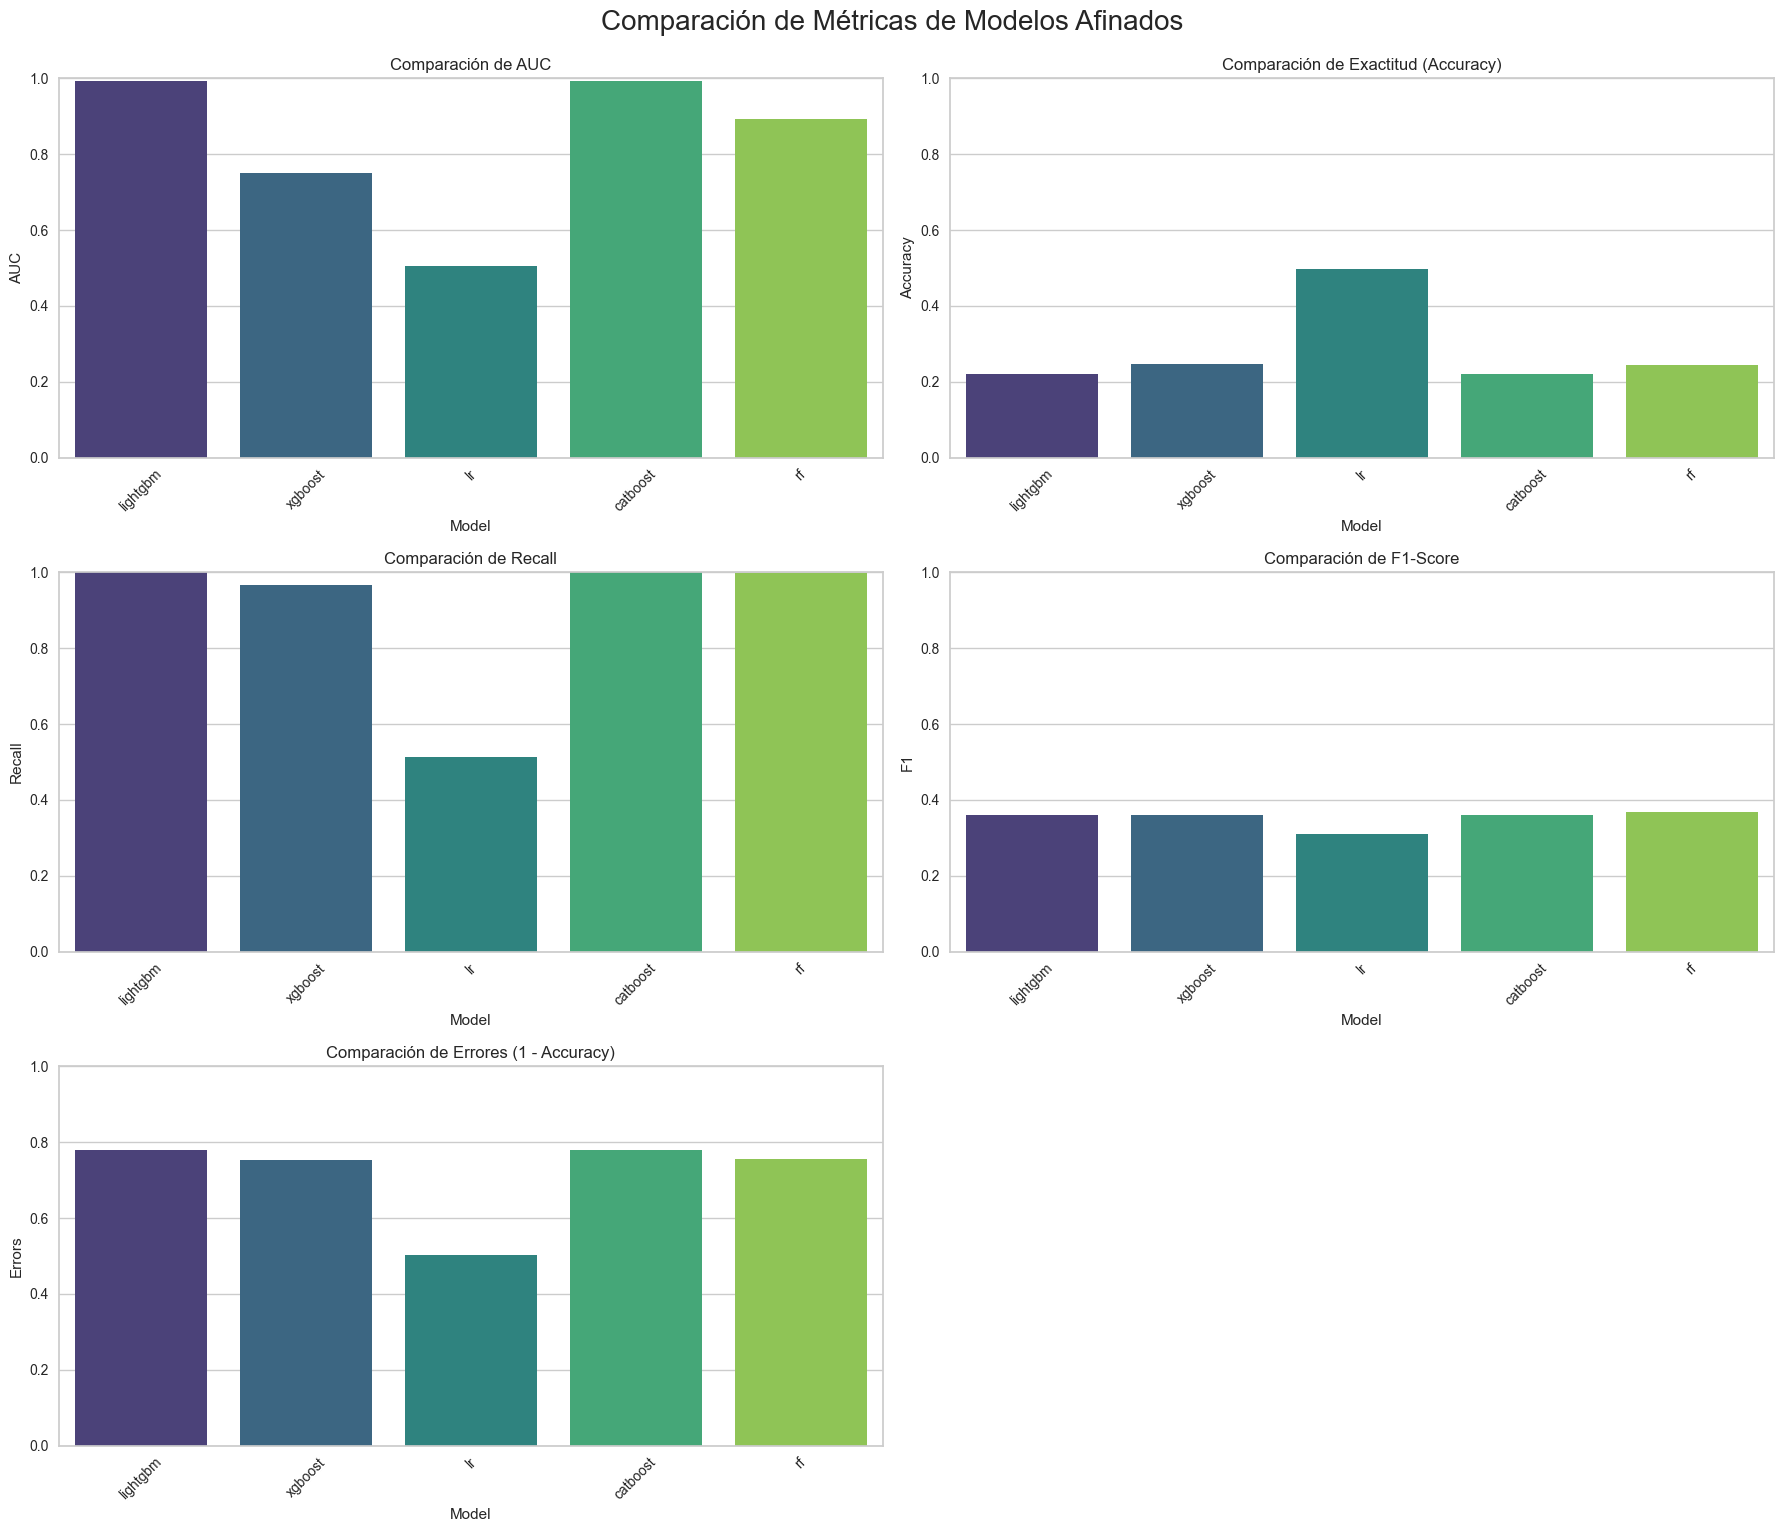

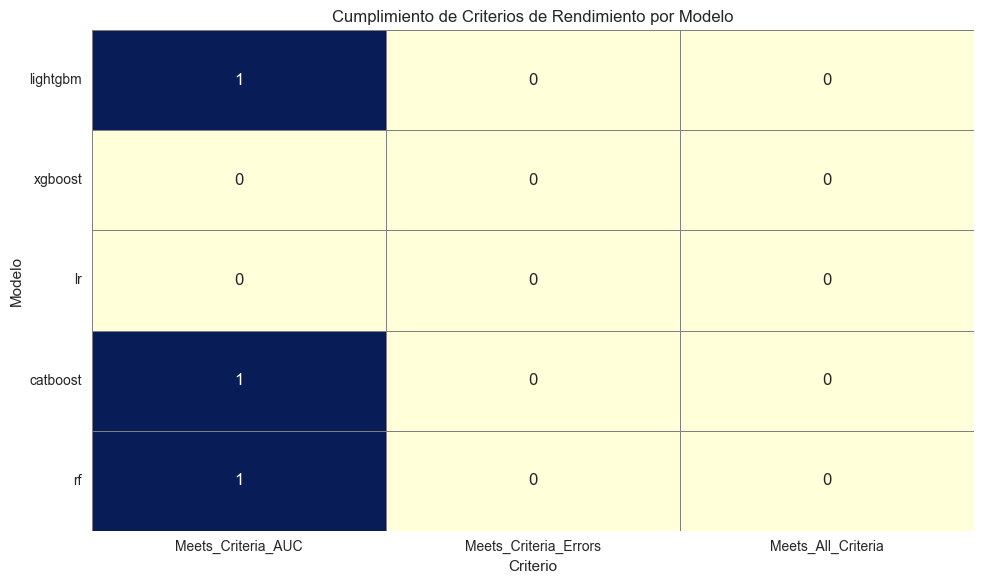


Análisis y gráficos comparativos completados.


In [24]:
print("\n============================================================")
print("RESUMEN DE MÉTRICAS DE TODOS LOS MODELOS AFINADOS")
print("============================================================")

metrics_df = pd.DataFrame(metrics_results).set_index('Model')
print(metrics_df)
# ============================================================
# VALIDACIÓN DE ALGORITMOS MEDIANTE MÉTRICAS
# ============================================================
print("\n============================================================")
print("VALIDACIÓN DE ALGORITMOS (Criterios: AUC > 0.85, Errores < 0.5)")
print("============================================================")

metrics_df['Errors'] = 1 - metrics_df['Accuracy']
metrics_df['Meets_Criteria_AUC'] = metrics_df['AUC'] > 0.85
metrics_df['Meets_Criteria_Errors'] = metrics_df['Errors'] < 0.5
metrics_df['Meets_All_Criteria'] = metrics_df['Meets_Criteria_AUC'] & metrics_df['Meets_Criteria_Errors']

print(metrics_df[['AUC', 'Errors', 'Meets_Criteria_AUC', 'Meets_Criteria_Errors', 'Meets_All_Criteria']])

# ============================================================
# GRÁFICAS COMPARATIVAS DE MÉTRICAS
# ============================================================
print("\n============================================================")
print("GENERANDO GRÁFICOS COMPARATIVOS DE MÉTRICAS")
print("============================================================")

metrics_plot_df = metrics_df.reset_index().melt(id_vars='Model', value_vars=['AUC', 'Accuracy', 'Recall', 'F1', 'Errors'], var_name='Metric', value_name='Score')

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))
axes = axes.flatten()

metrics_to_plot = ['AUC', 'Accuracy', 'Recall', 'F1', 'Errors']
titles = {
    'AUC': 'Comparación de AUC',
    'Accuracy': 'Comparación de Exactitud (Accuracy)',
    'Recall': 'Comparación de Recall',
    'F1': 'Comparación de F1-Score',
    'Errors': 'Comparación de Errores (1 - Accuracy)'
}

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(x='Model', y='Score', data=metrics_plot_df[metrics_plot_df['Metric'] == metric], ax=axes[i], palette='viridis')
    axes[i].set_title(titles[metric])
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylim(0, 1)

if len(metrics_to_plot) < len(axes):
    for j in range(len(metrics_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Comparación de Métricas de Modelos Afinados', y=1.02, fontsize=20)
plt.show()

# Gráfico de cumplimiento de criterios
plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df[['Meets_Criteria_AUC', 'Meets_Criteria_Errors', 'Meets_All_Criteria']].astype(int),
            annot=True, cmap='YlGnBu', fmt='d', cbar=False, linewidths=.5, linecolor='gray')
plt.title('Cumplimiento de Criterios de Rendimiento por Modelo')
plt.xlabel('Criterio')
plt.ylabel('Modelo')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nAnálisis y gráficos comparativos completados.")

## Cargar Modelos si se tienen los archivos .pkl (Muy alta probabilidad de AUC de 0.5 si se tiene diferente setup)

In [22]:
##### POSIBLE QUE AUC RESULTE EN 0.5

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef
)
# Obtener el nombre de la columna objetivo del setup
target_col_name = master_setup.get_config('target_param') # ¡CORREGIDO!

# Inicializar las listas/diccionarios que contendrán los resultados
metrics_results = [] # Aquí se almacenarán las métricas de todos los modelos
final_models = {}    # No es estrictamente necesario para las métricas, pero útil si quieres acceder a los modelos cargados


# --- 1. CARGAR Y EVALUAR TODOS LOS MODELOS GUARDADOS ---
# Definir la lista de todos tus modelos guardados y sus nombres de archivo .pkl
model_files = {
    'LightGBM': 'final_lightgbm_model_fixed_params',
    'XGBoost': 'final_xgboost_model_fixed_params',
    'Logistic Regression': 'final_lr_model_fixed_params',
    'CatBoost': 'final_catboost_model_fixed_params',
    'Random Forest': 'final_random_forest_model_fixed_params'
}

print("============================================================")
print("EVALUANDO TODOS LOS MODELOS GUARDADOS EN EL CONJUNTO DE PRUEBA")
print("============================================================")

for model_display_name, file_name in model_files.items():
    print(f"\n--- Evaluando: {model_display_name} ({file_name}) ---")
    try:
        # Cargar el modelo desde el archivo .pkl
        loaded_model = load_model(file_name)
        print(f"  Modelo '{model_display_name}' cargado exitosamente.")

        # Hacer predicciones en el conjunto de prueba interno de PyCaret
        predictions = predict_model(loaded_model, verbose=False)
        print("  Predicciones realizadas en el conjunto de prueba.")

        # Calcular todas las métricas deseadas
        y_true = predictions[target_col_name]
        y_pred = predictions['prediction_label']
        y_proba = predictions['prediction_score'] # Probabilidades para AUC

        report = classification_report(y_true, y_pred, output_dict=True, zero_division=0) # zero_division=0 para evitar warnings
        auc_score = roc_auc_score(y_true, y_proba)
        kappa_score = cohen_kappa_score(y_true, y_pred)
        mcc_score = matthews_corrcoef(y_true, y_pred)

        # Manejo de casos donde la clase '1' no esté en el reporte si no hay predicciones/reales
        recall_val = report['1']['recall'] if '1' in report else (report['macro avg']['recall'] if 'macro avg' in report else np.nan)
        prec_val = report['1']['precision'] if '1' in report else (report['macro avg']['precision'] if 'macro avg' in report else np.nan)
        f1_val = report['1']['f1-score'] if '1' in report else (report['macro avg']['f1-score'] if 'macro avg' in report else np.nan)


        metrics_results.append({
            'Model': model_display_name,
            'AUC': auc_score,
            'Accuracy': report['accuracy'],
            'Recall': recall_val,
            'Prec.': prec_val,
            'F1': f1_val,
            'Kappa': kappa_score,
            'MCC': mcc_score
        })
        print(f"  Métricas para '{model_display_name}' calculadas.")

    except Exception as e:
        print(f"  Error al procesar el modelo '{model_display_name}': {e}")
        # Asegúrate de que todas las columnas existan, incluso si hay un error
        metrics_results.append({'Model': model_display_name, 'AUC': np.nan, 'Accuracy': np.nan,
                                'Recall': np.nan, 'Prec.': np.nan, 'F1': np.nan,
                                'Kappa': np.nan, 'MCC': np.nan})

# --- 2. MOSTRAR RESUMEN Y GRÁFICOS (TU CÓDIGO ACTUAL) ---
# Ahora que `metrics_results` contiene todas las métricas de todos los modelos
# puedes usar tu código de resumen y gráficos directamente.

print("\n============================================================")
print("RESUMEN DE MÉTRICAS DE TODOS LOS MODELOS AFINADOS")
print("============================================================")

metrics_df = pd.DataFrame(metrics_results).set_index('Model')
print(metrics_df)

EVALUANDO TODOS LOS MODELOS GUARDADOS EN EL CONJUNTO DE PRUEBA

--- Evaluando: LightGBM (final_lightgbm_model_fixed_params) ---
Transformation Pipeline and Model Successfully Loaded
  Modelo 'LightGBM' cargado exitosamente.
  Predicciones realizadas en el conjunto de prueba.
  Métricas para 'LightGBM' calculadas.

--- Evaluando: XGBoost (final_xgboost_model_fixed_params) ---
Transformation Pipeline and Model Successfully Loaded
  Modelo 'XGBoost' cargado exitosamente.
  Predicciones realizadas en el conjunto de prueba.
  Métricas para 'XGBoost' calculadas.

--- Evaluando: Logistic Regression (final_lr_model_fixed_params) ---
Transformation Pipeline and Model Successfully Loaded
  Modelo 'Logistic Regression' cargado exitosamente.
  Predicciones realizadas en el conjunto de prueba.
  Métricas para 'Logistic Regression' calculadas.

--- Evaluando: CatBoost (final_catboost_model_fixed_params) ---
Transformation Pipeline and Model Successfully Loaded
  Modelo 'CatBoost' cargado exitosament